Loading dataset ...
Shape: 3430 rows x 171 columns

Total numeric features   : 161
Used in model + ranked   : 137
Used in model, NOT ranked: 24  (PROMICE / surface-T exclusions)

Excluded from ranking:
  - AirTemperature(C)
  - AirTemperatureHygroClip(C)
  - IceTemperature1(C)
  - IceTemperature2(C)
  - IceTemperature3(C)
  - IceTemperature4(C)
  - IceTemperature5(C)
  - IceTemperature6(C)
  - IceTemperature7(C)
  - IceTemperature8(C)
  - SurfaceTemperature(C)
  - caf_promice
  - caf_promice_pia
  - ist_1tdomain
  - ist_3tdomain
  - istsim_1tdomain
  - istsim_3tdomain
  - lev2_surface_temperature
  - lev2_t2m
  - nwp_d2m
  - nwp_q2m
  - nwp_skt
  - nwp_t2m
  - promistK

Rows used: 3430

Target (ist_promice): mean=248.98  std=13.61  min=211.67  median=250.26  max=270.00

Training Gradient Boosting model (all features, including exclusions) ...
Test R2 = 1.0000   RMSE = 0.0441 K

Computing P10-P90 sensitivity for 137 rankable features ...
  Metric: delta_IST = mean|d(IST)/d(feat)| x (P90

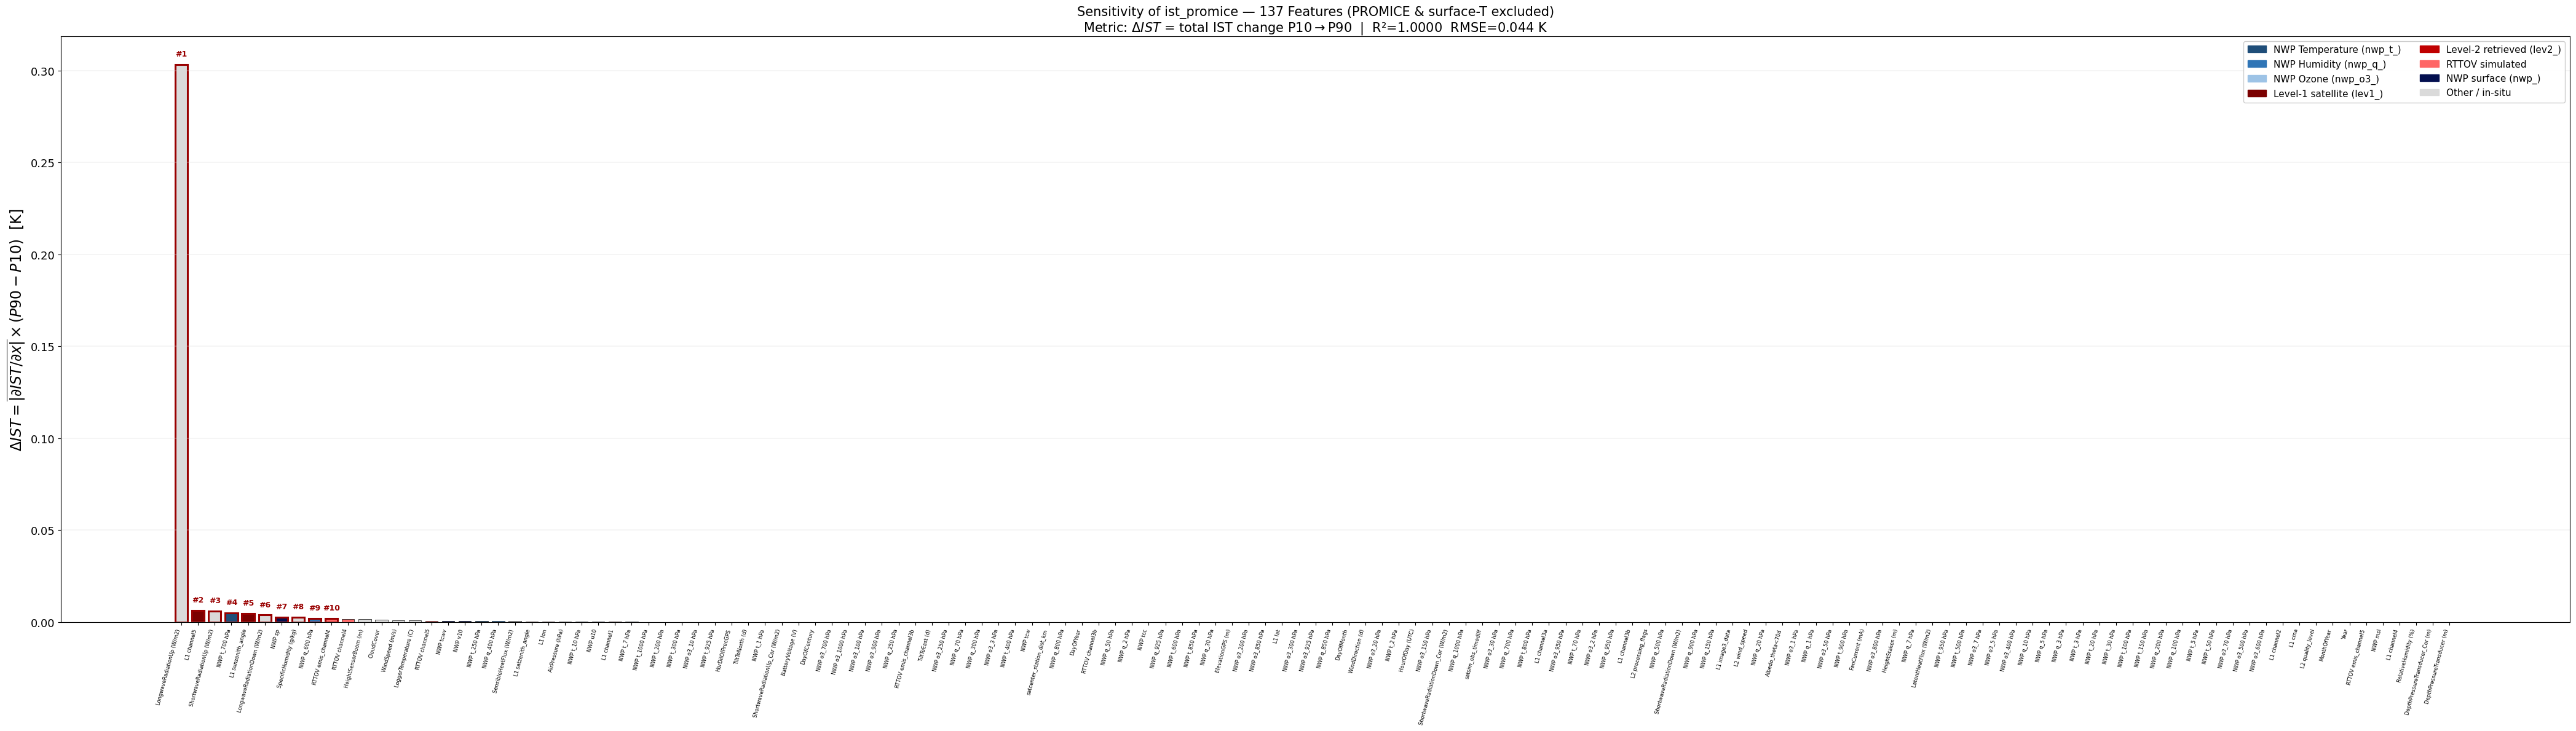

  Saved: sensitivity_all_features_bar.png

[2/5] Plotting AMSR-style sensitivity plots for top-10 features ...


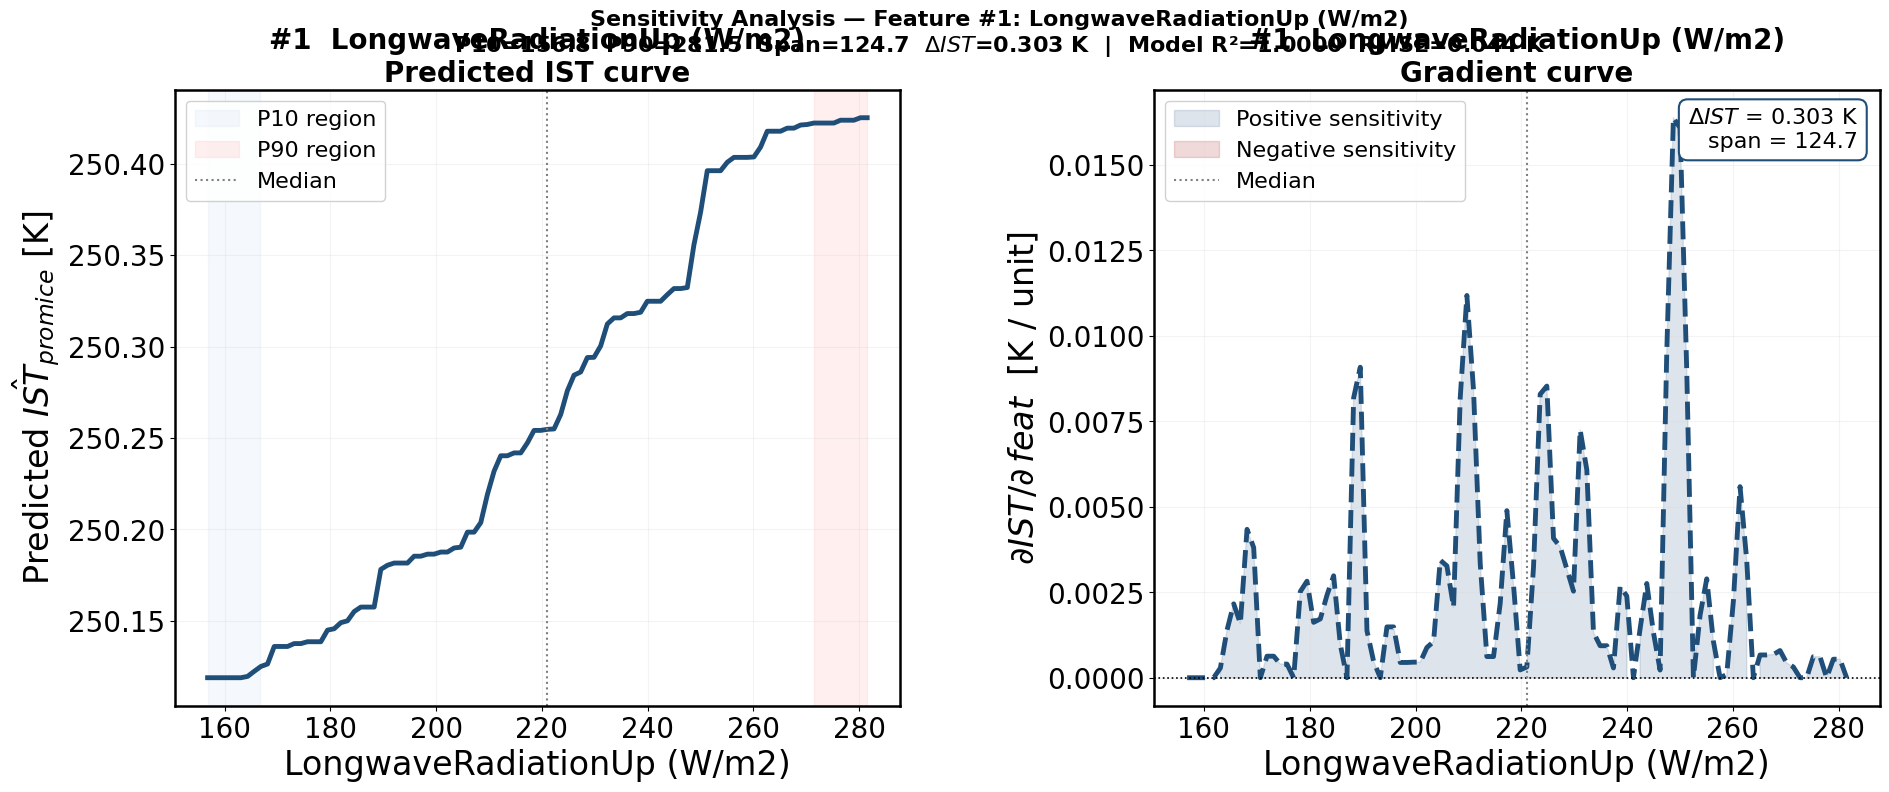

  # 1  Saved: sensitivity_top01_LongwaveRadiationUpW_m2.png


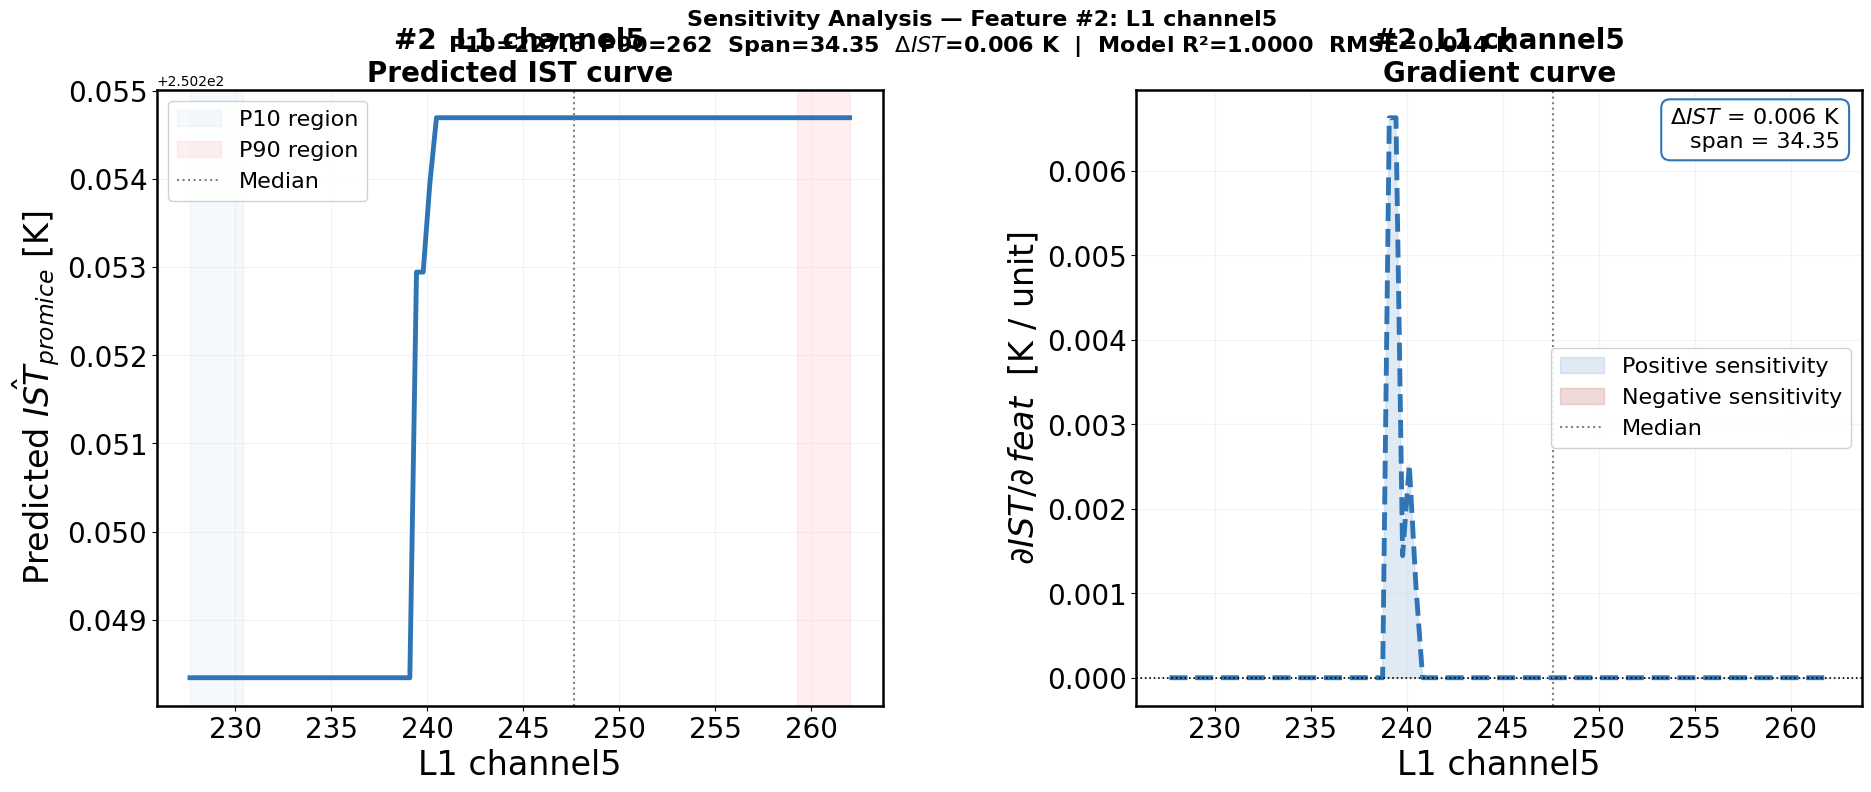

  # 2  Saved: sensitivity_top02_lev1_channel5.png


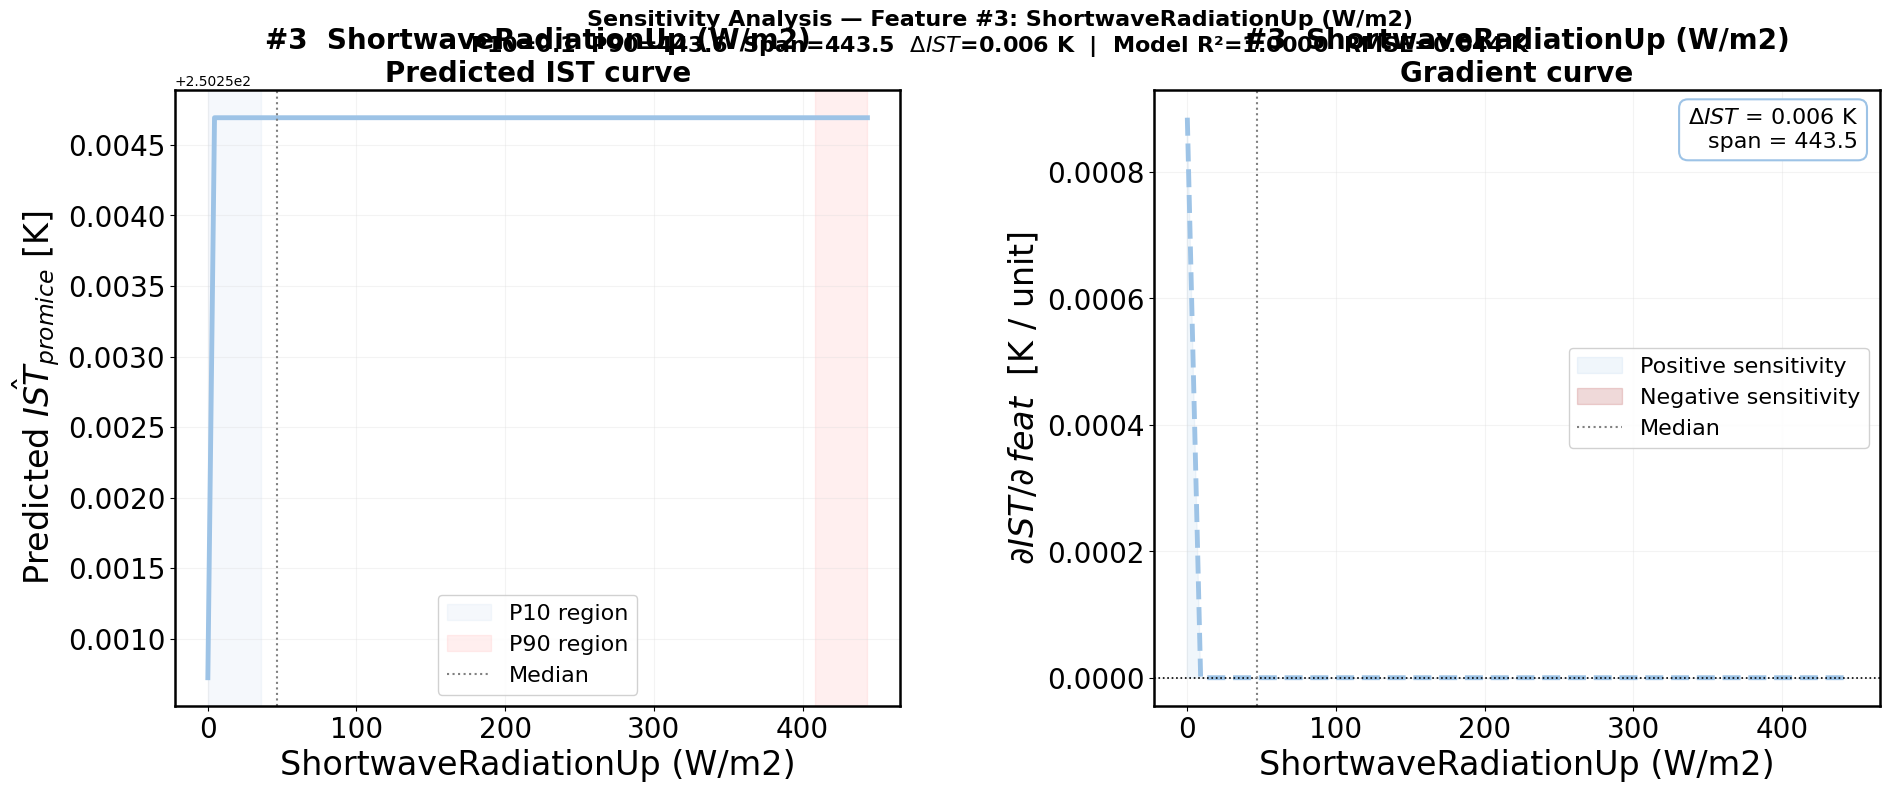

  # 3  Saved: sensitivity_top03_ShortwaveRadiationUpW_m2.png


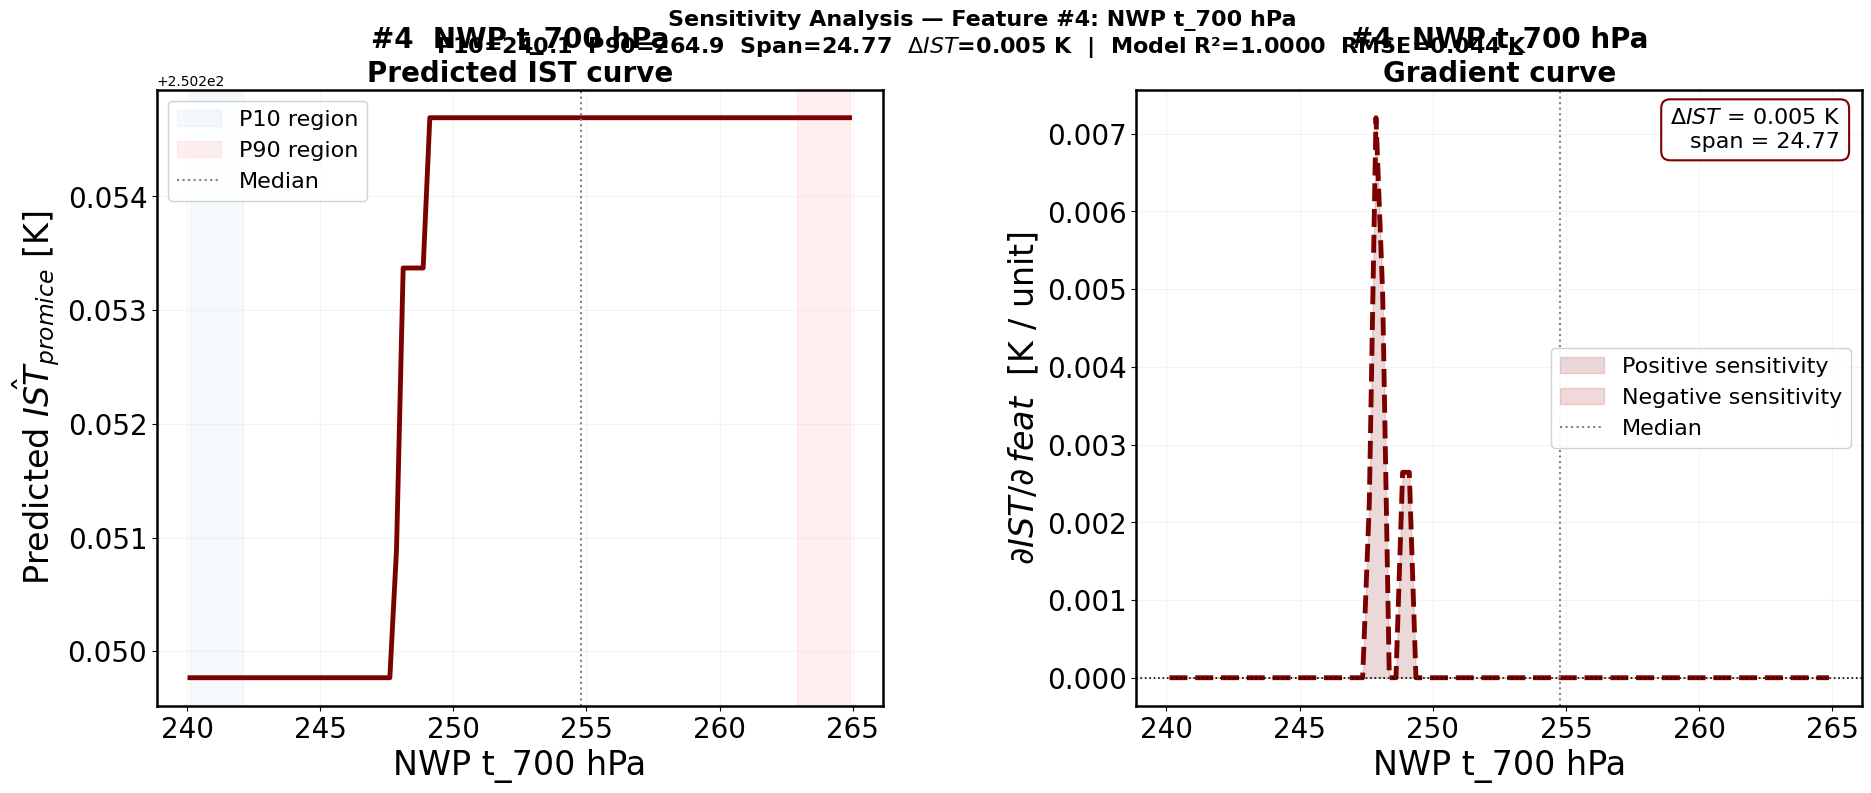

  # 4  Saved: sensitivity_top04_nwp_t_700_hPa.png


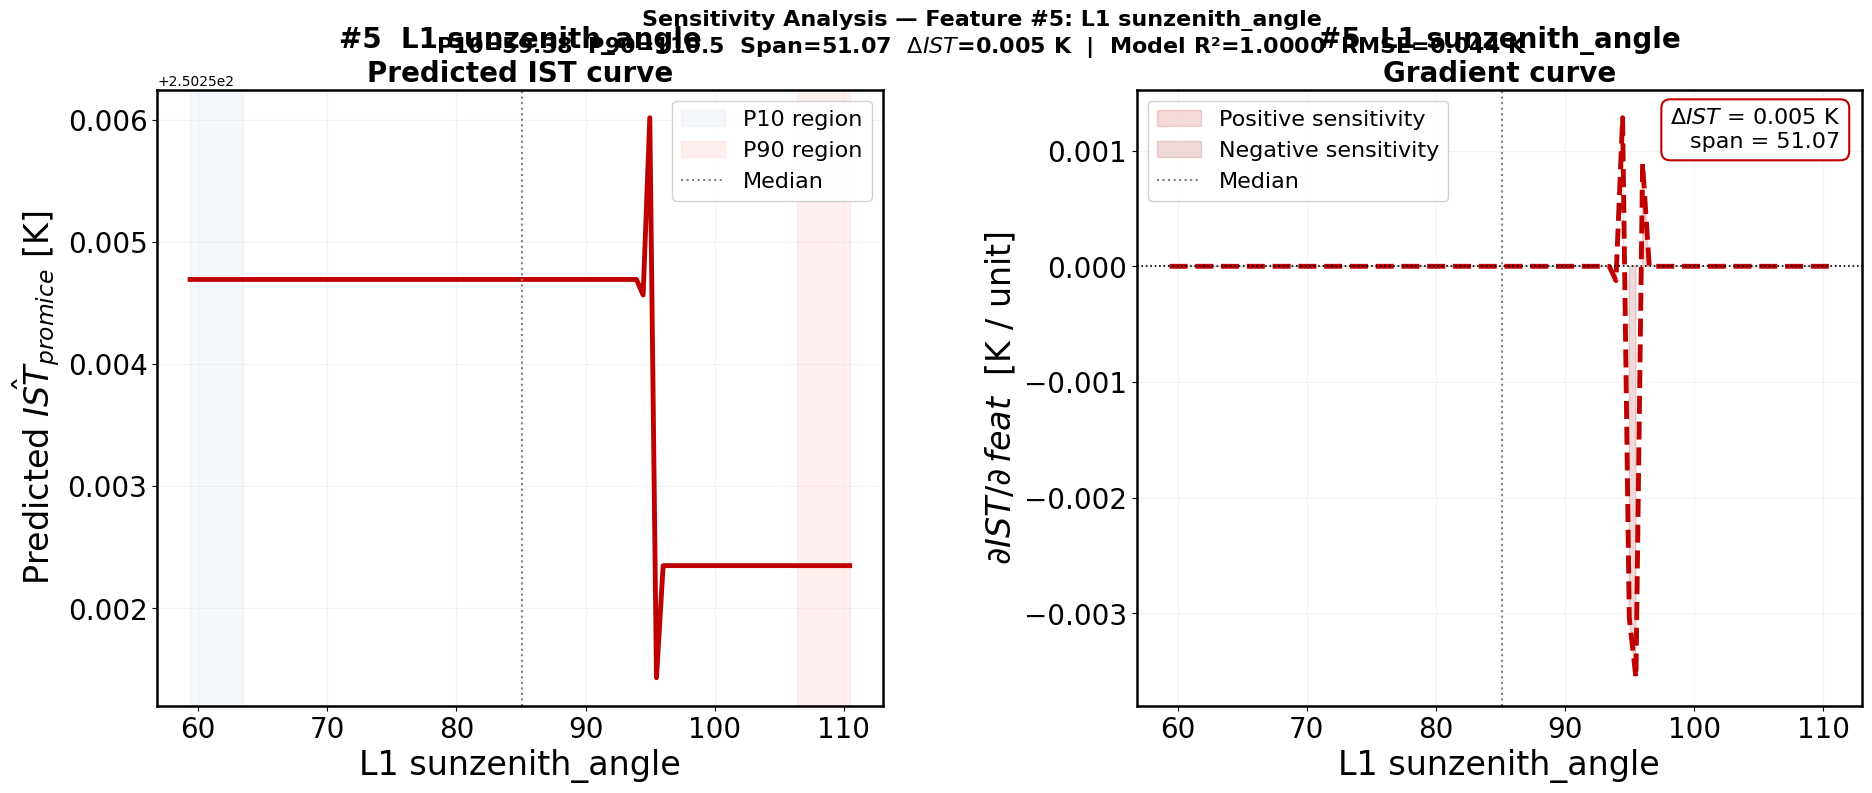

  # 5  Saved: sensitivity_top05_lev1_sunzenith_angle.png


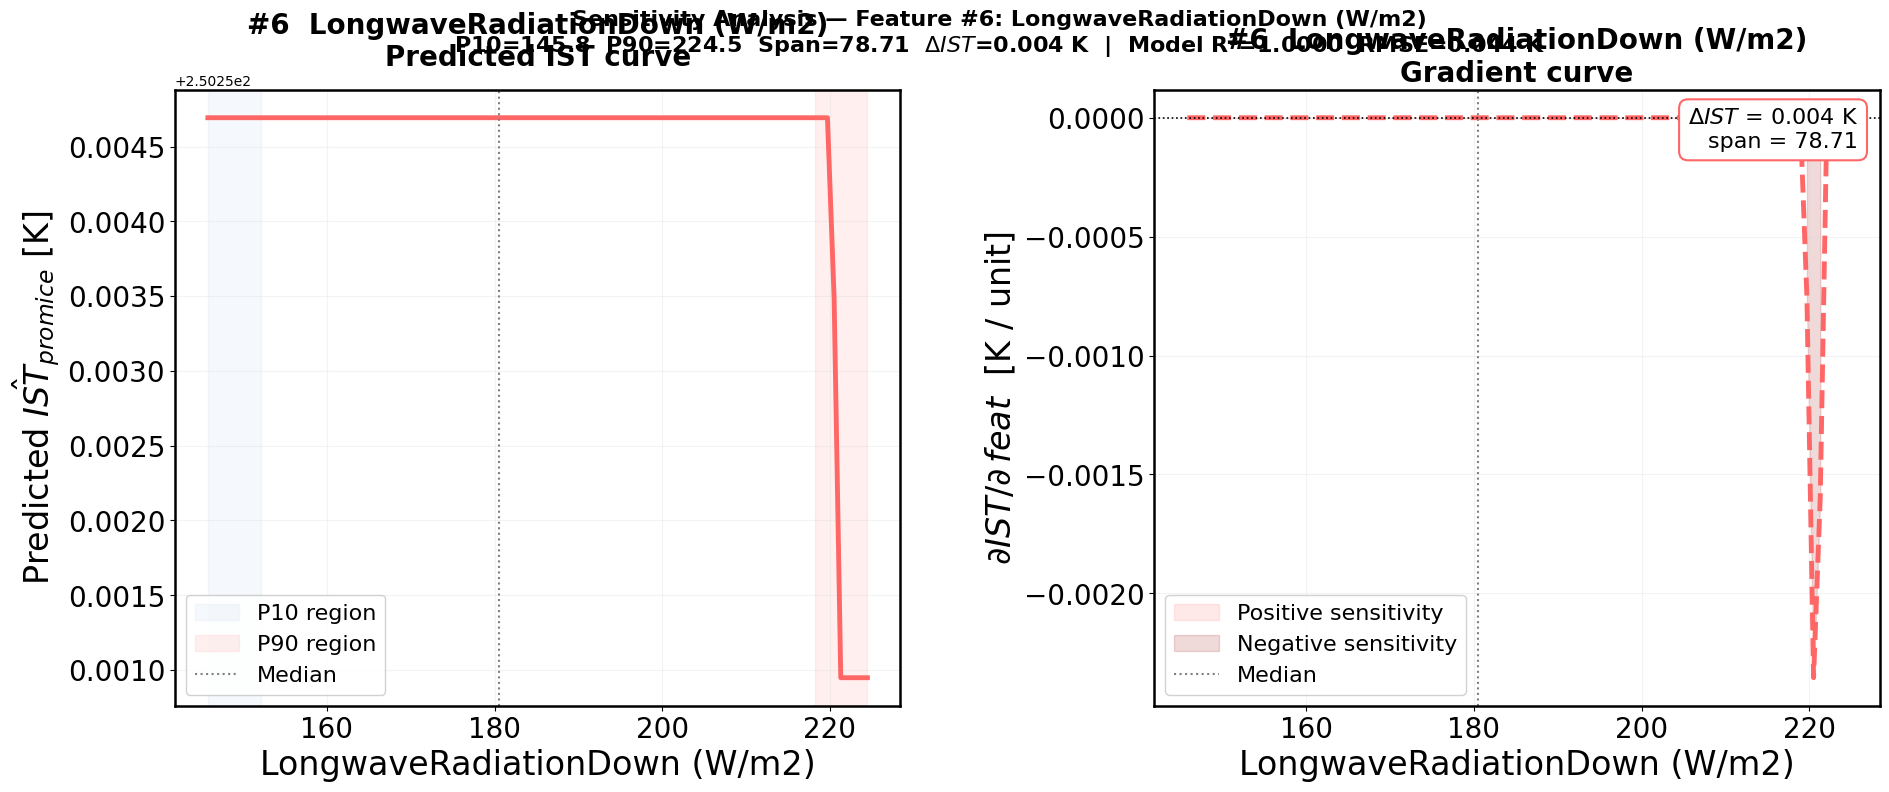

  # 6  Saved: sensitivity_top06_LongwaveRadiationDownW_m2.png


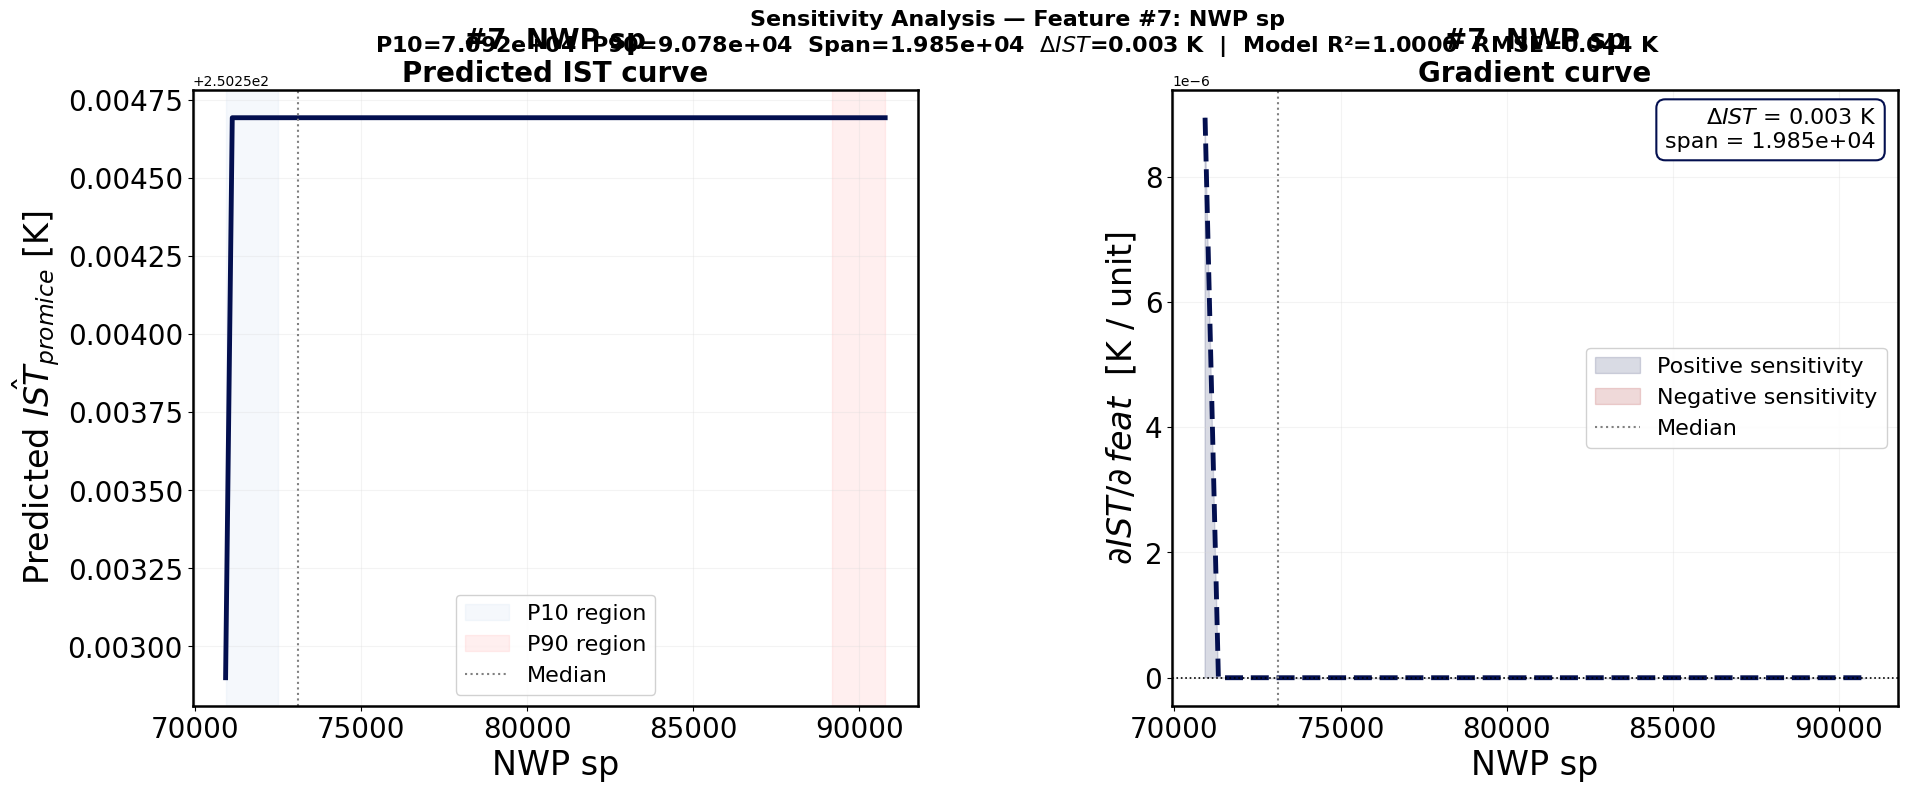

  # 7  Saved: sensitivity_top07_nwp_sp.png


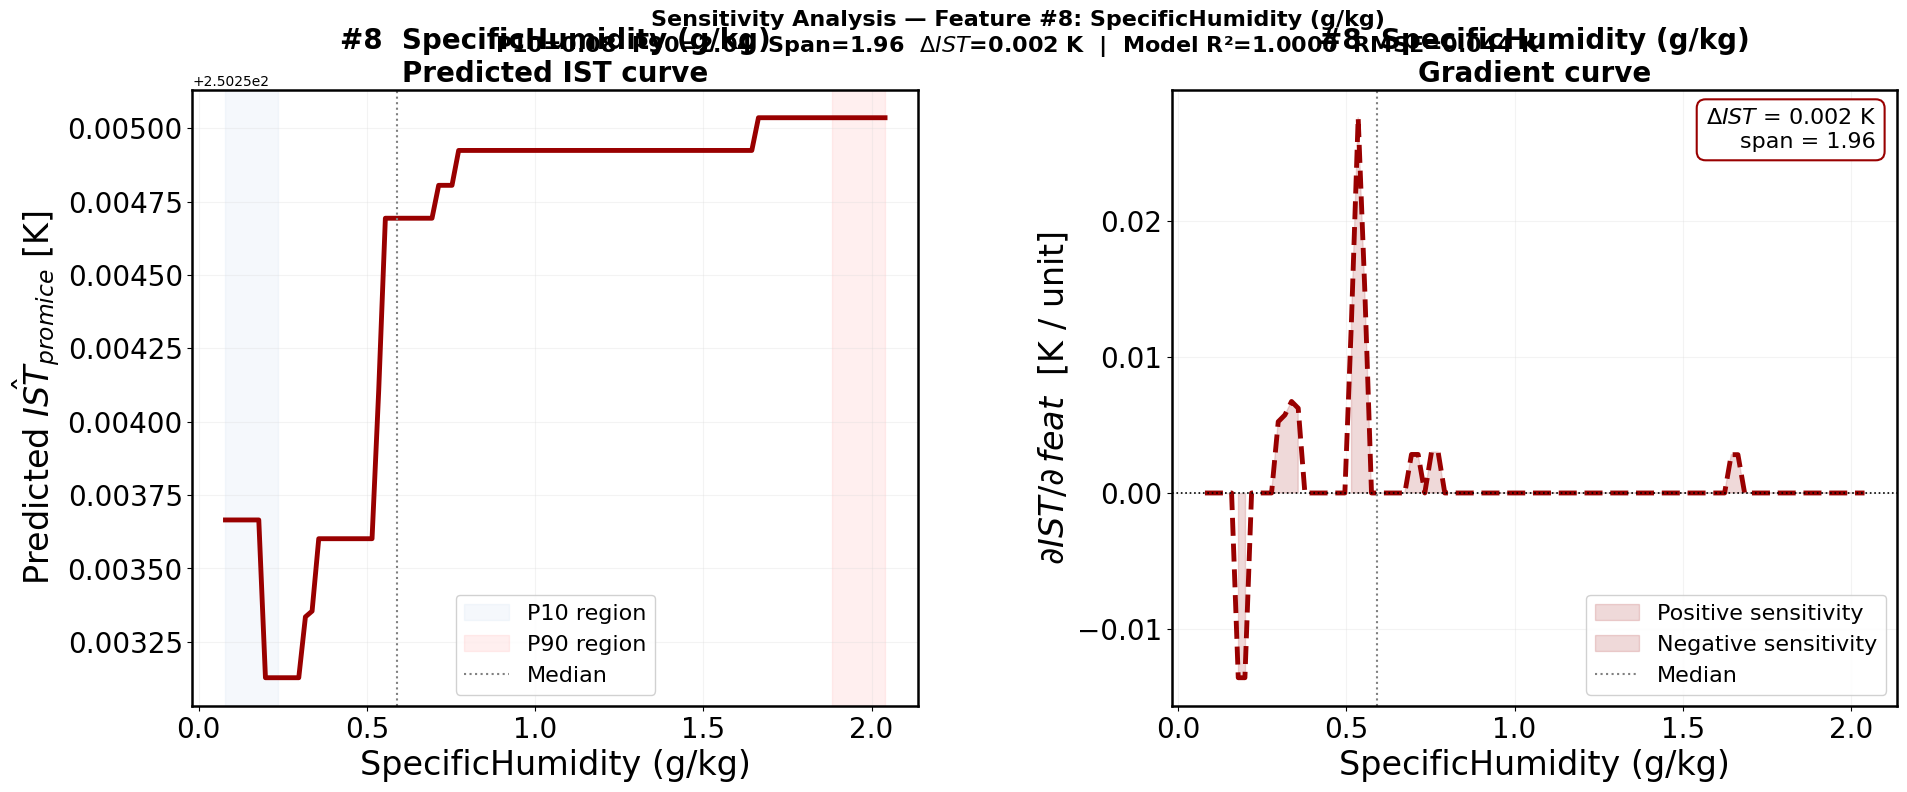

  # 8  Saved: sensitivity_top08_SpecificHumidityg_kg.png


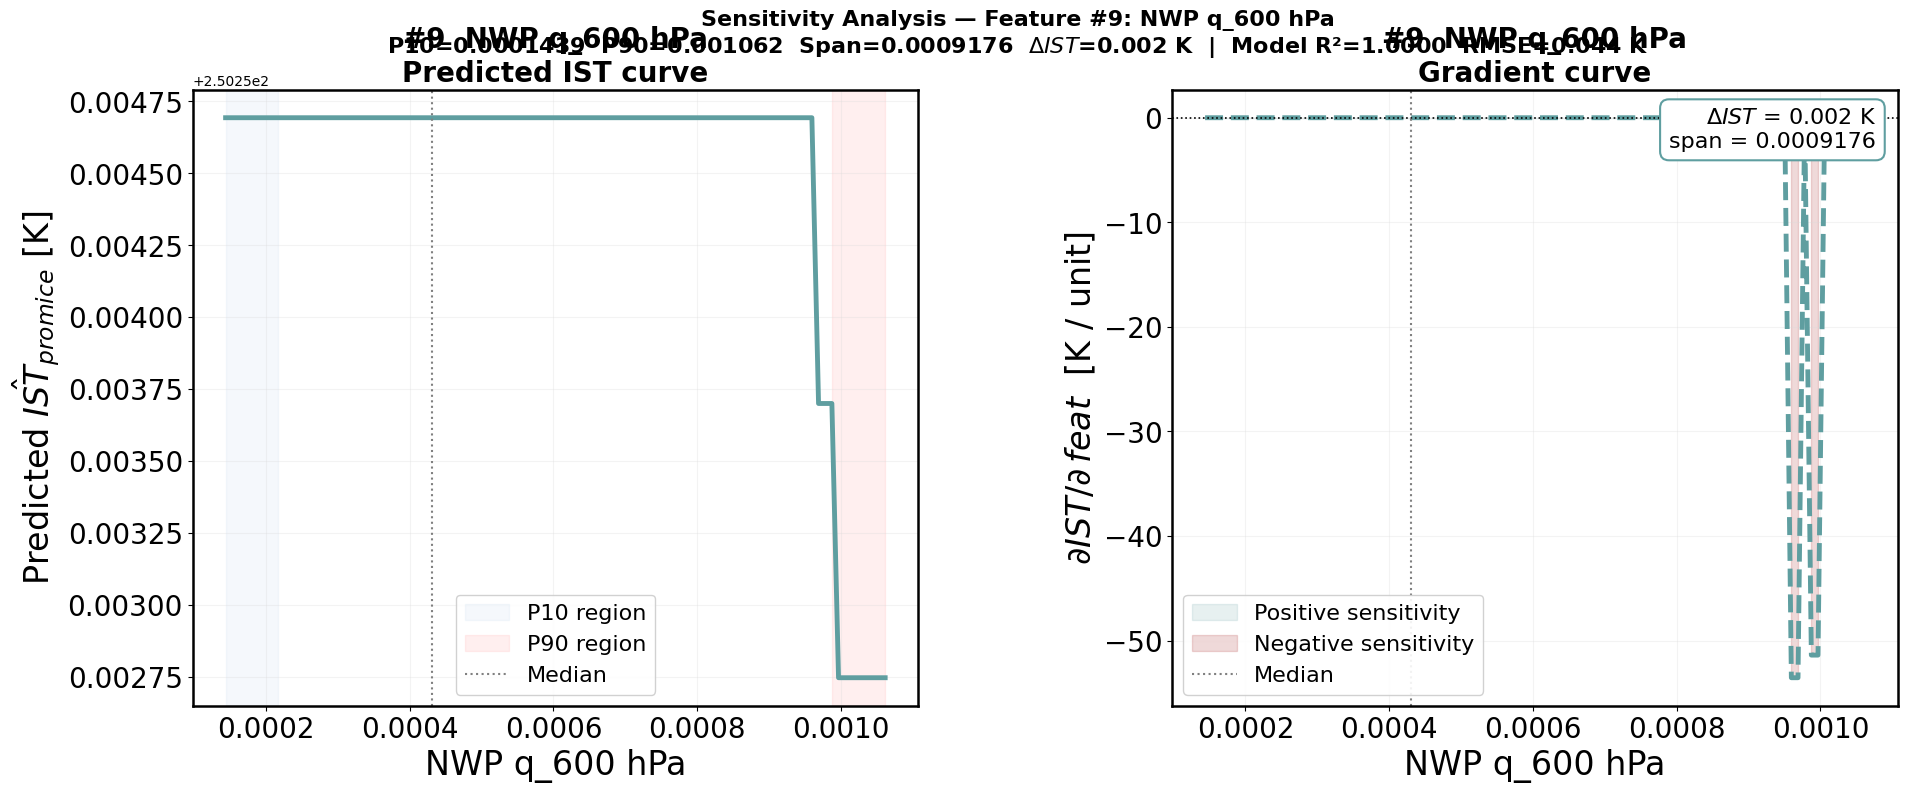

  # 9  Saved: sensitivity_top09_nwp_q_600_hPa.png


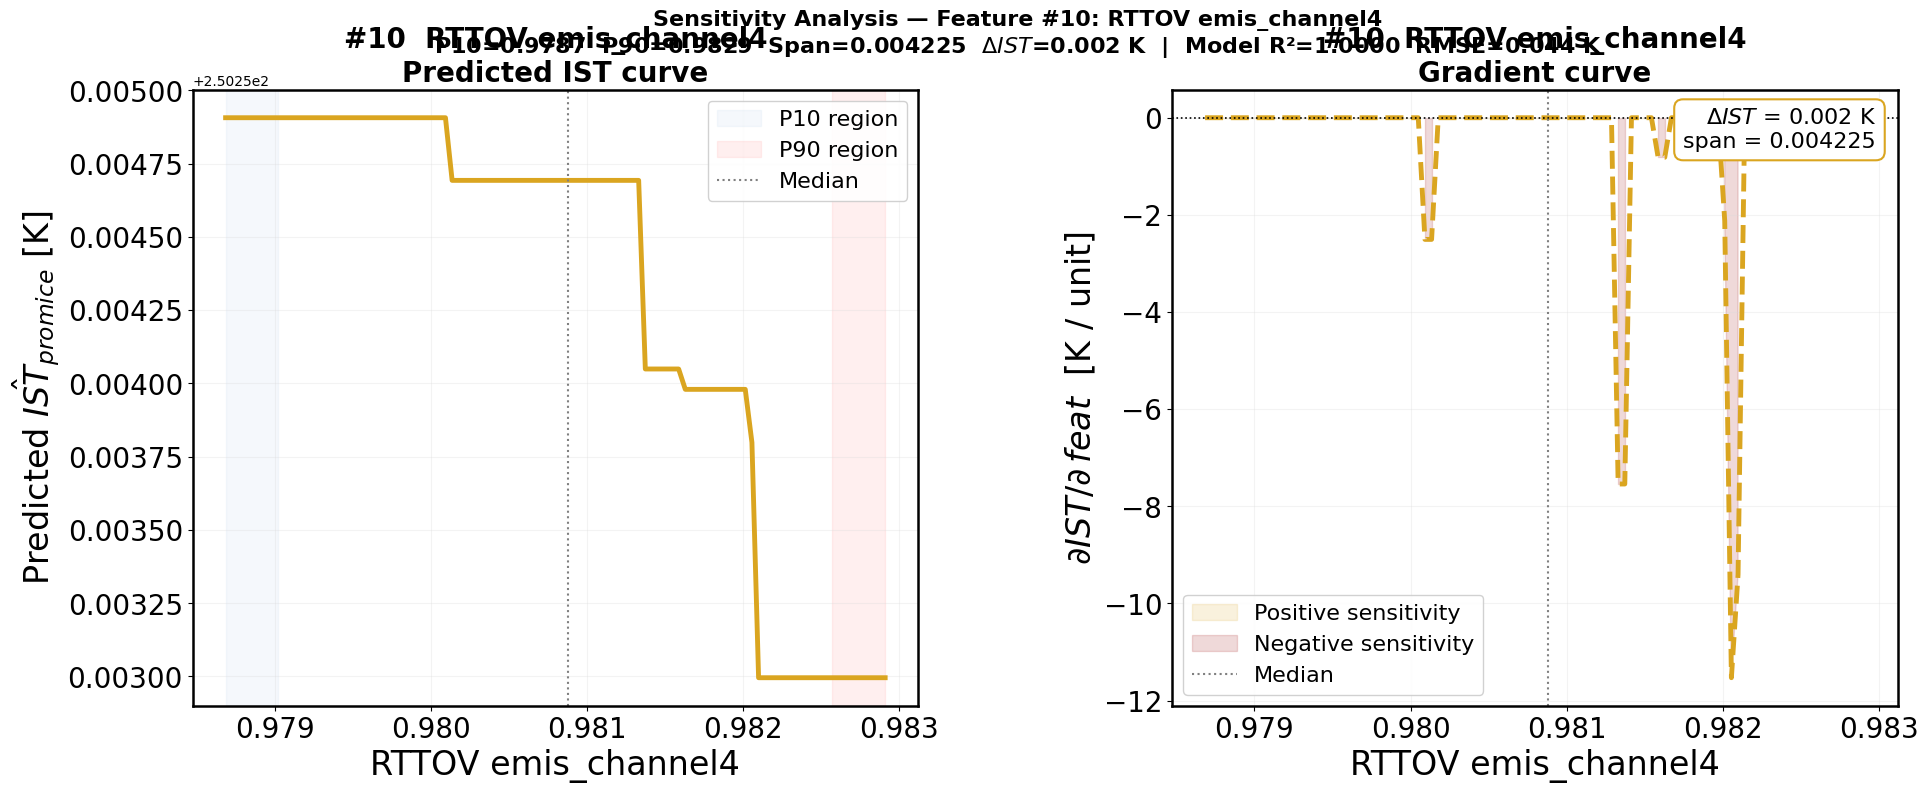

  #10  Saved: sensitivity_top10_rttov_emis_channel4.png

[3/5] Plotting combined top-10 gradient overview ...


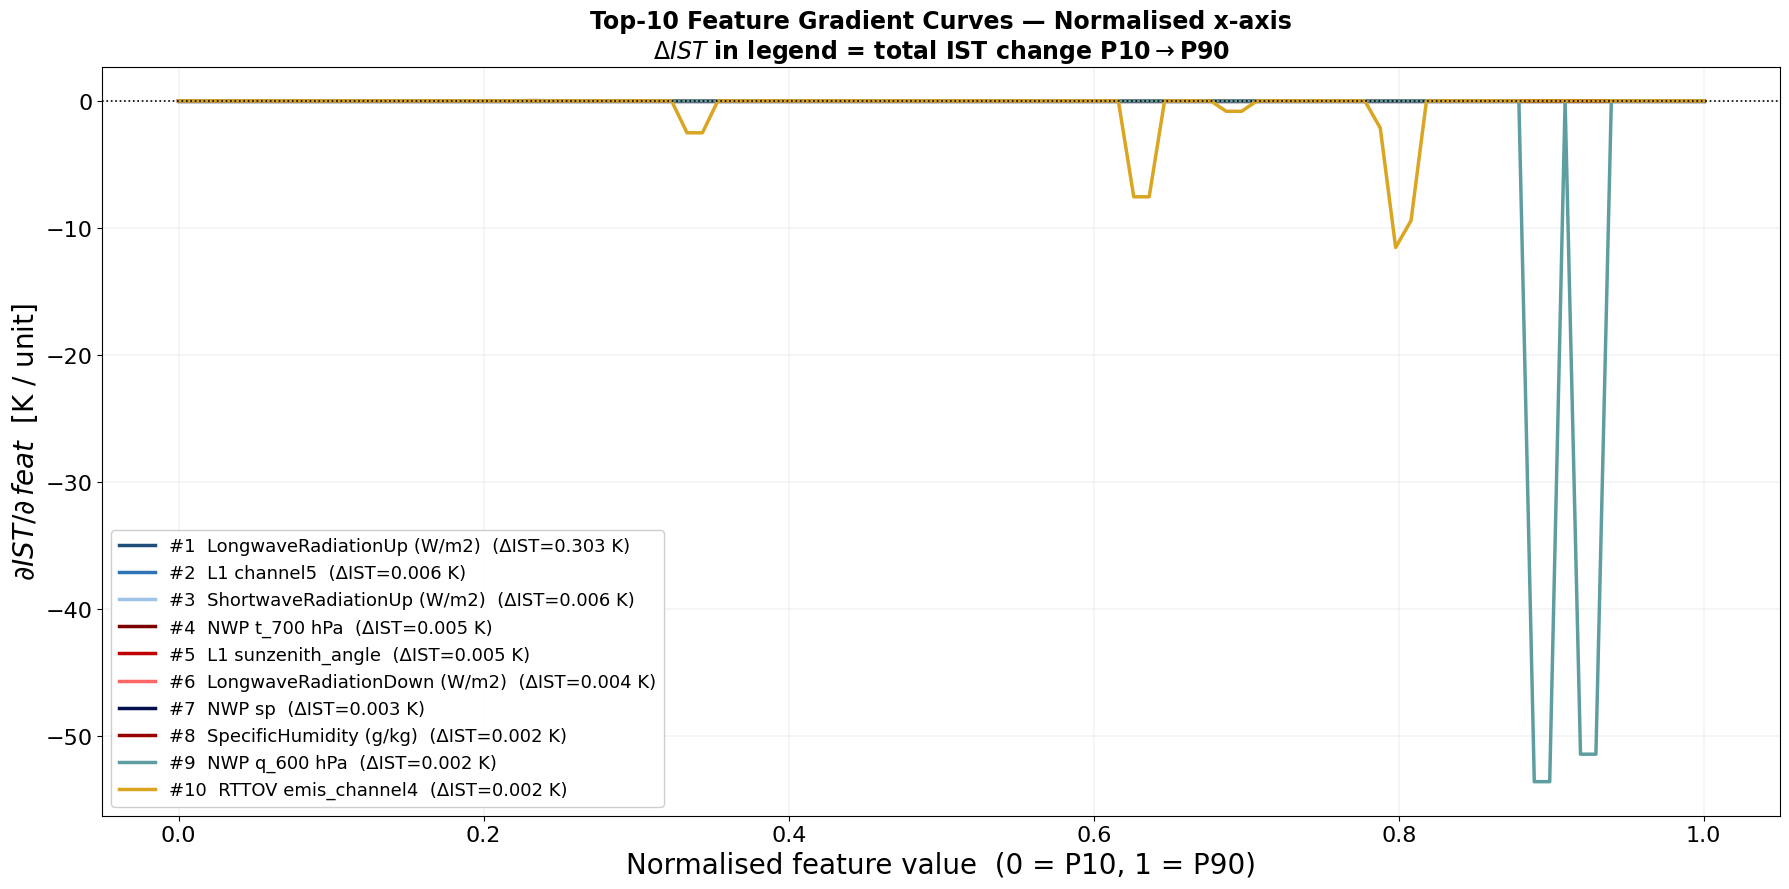

  Saved: sensitivity_top10_combined_gradients.png

[4/5] Plotting NWP profile heatmap ...


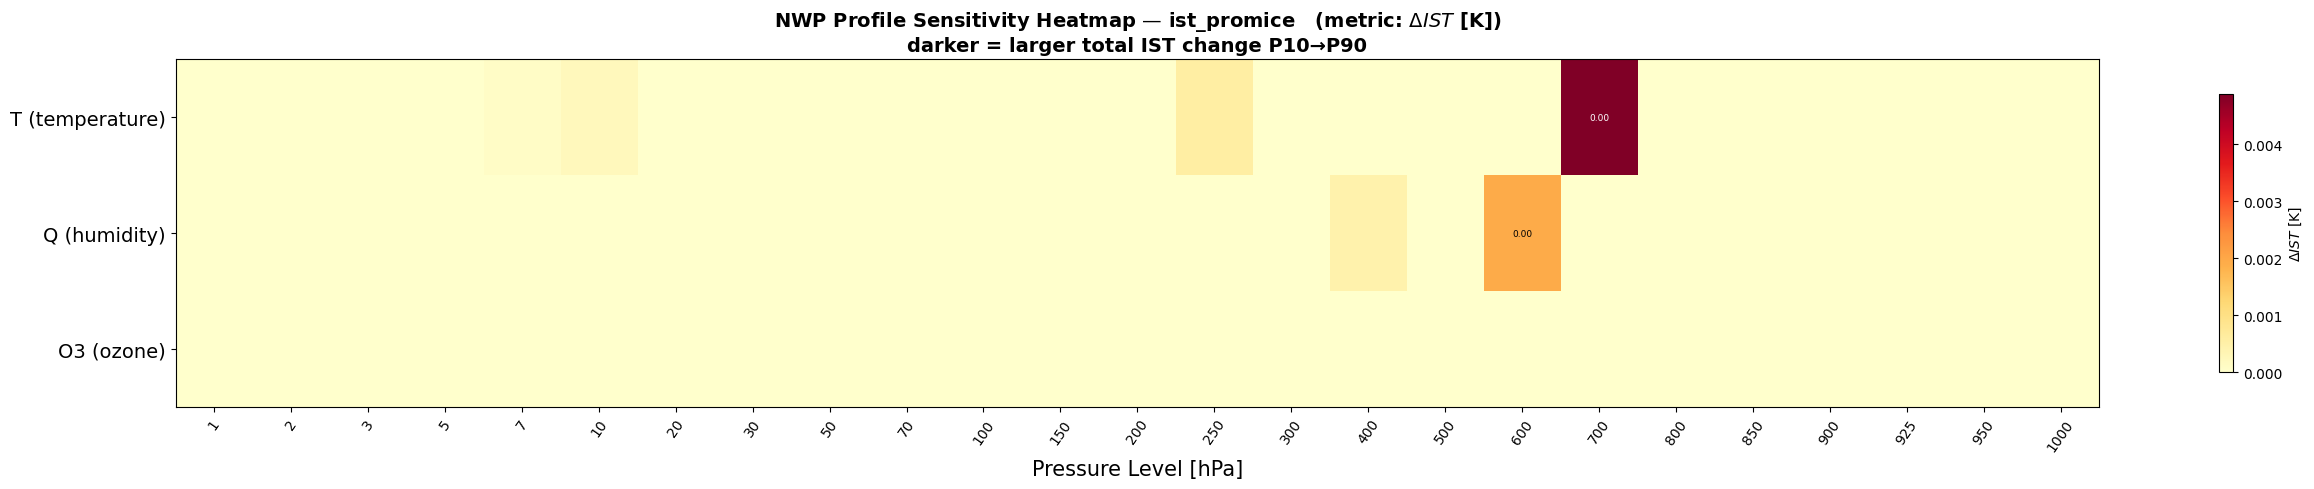

  Saved: sensitivity_heatmap_profiles.png

[5/5] Plotting top-10 close-up bar chart ...


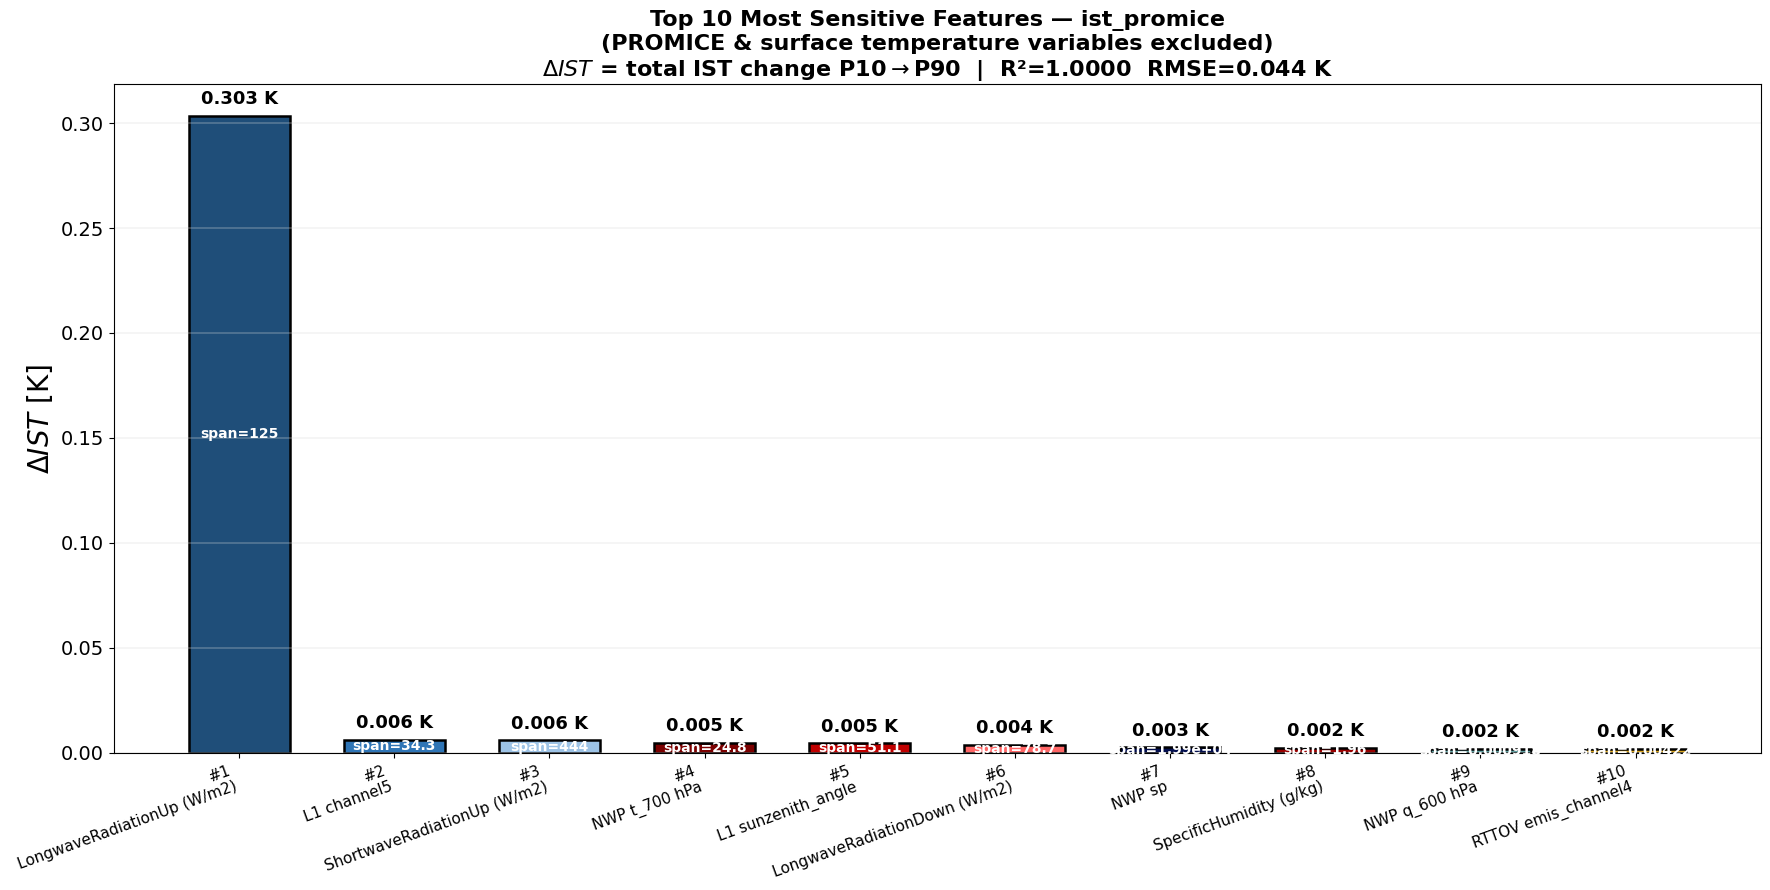

  Saved: sensitivity_top10_bar.png

Printing LaTeX longtable (all rankable features) ...
% Requires: \usepackage{longtable, booktabs} in preamble
\begin{longtable}{r l r r r r r}
\caption{Sensitivity of ist\_promice (PROMICE \& surface-T variables excluded). Metric: $\Delta IST$ [K].}
\label{tab:ist_sensitivity_all} \\
\toprule
Rank & Feature & P10 & P90 & Span & $\overline{|\partial IST/\partial x|}$ & $\Delta IST$ [K] \\
\midrule \endfirsthead
\multicolumn{7}{c}{\textit{(continued)}} \\ \toprule
Rank & Feature & P10 & P90 & Span & $\overline{|\partial IST/\partial x|}$ & $\Delta IST$ [K] \\
\midrule \endhead \bottomrule \endfoot
1 & \texttt{LongwaveRadiationUp(W/m2)} $\bigstar$ & 156.8 & 281.5 & 124.7 & 0.0024 & 0.3034 \\
2 & \texttt{lev1\_channel5} $\bigstar$ & 227.6 & 262 & 34.35 & 0.0002 & 0.0063 \\
3 & \texttt{ShortwaveRadiationUp(W/m2)} $\bigstar$ & 0.1 & 443.6 & 443.5 & 0.0000 & 0.0059 \\
4 & \texttt{nwp\_t\_700\_hPa} $\bigstar$ & 240.1 & 264.9 & 24.77 & 0.0002 & 0.0049 \\
5 & 

In [9]:
"""
============================================================================
Sensitivity Analysis: ist_promice — ALL FEATURES
PROMICE dataset — filter_mu_atmo_surf_obs2345_promistK.csv

Method: P10-P90 gradient-based sensitivity using Gradient Boosting model
        delta_IST = mean|d(IST)/d(feat)| × (P90 - P10)  [K]

EXCLUSIONS from ranking (used in model training but NOT ranked):
  - Any variable containing 'promice', 'promist'   → direct target leakage
  - Surface / skin temperature variables            → trivially correlated
      nwp_skt, nwp_t2m, nwp_d2m, nwp_q2m
      lev2_surface_temperature, lev2_t2m
      SurfaceTemperature(C), AirTemperature(C),
      AirTemperatureHygroClip(C)
      IceTemperature1..8
      ist_1tdomain, ist_3tdomain, istsim_*
============================================================================
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
import warnings, math
warnings.filterwarnings('ignore')

# ─── DTU-style colour palette ────────────────────────────────────────────────
dtu_navy    = '#030F4F'
dtu_red     = '#990000'
dtu_grey    = '#DADADA'
black       = '#000000'
phase1_blue = '#1F4E79'
phase2_blue = '#2F75B6'
phase3_blue = '#9DC3E6'
phase1_red  = '#7B0000'
phase2_red  = '#C00000'
phase3_red  = '#FF6666'

TOP10_COLOURS = [
    phase1_blue, phase2_blue, phase3_blue,
    phase1_red,  phase2_red,  phase3_red,
    dtu_navy,    dtu_red,     '#5F9EA0',  '#DAA520'
]

def colour_for(name):
    n = name.lower()
    if 'nwp_t_'  in n: return phase1_blue
    if 'nwp_q_'  in n: return phase2_blue
    if 'nwp_o3_' in n: return phase3_blue
    if 'lev1_'   in n: return phase1_red
    if 'lev2_'   in n: return phase2_red
    if 'rttov_'  in n: return phase3_red
    if 'nwp_'    in n: return dtu_navy
    return dtu_grey

def short_label(name):
    return (name.replace('nwp_', 'NWP ')
                .replace('lev1_', 'L1 ')
                .replace('lev2_', 'L2 ')
                .replace('rttov_', 'RTTOV ')
                .replace('_hPa', ' hPa')
                .replace('(', '\n('))

LEGEND_PATCHES = [
    mpatches.Patch(color=phase1_blue, label='NWP Temperature (nwp_t_)'),
    mpatches.Patch(color=phase2_blue, label='NWP Humidity (nwp_q_)'),
    mpatches.Patch(color=phase3_blue, label='NWP Ozone (nwp_o3_)'),
    mpatches.Patch(color=phase1_red,  label='Level-1 satellite (lev1_)'),
    mpatches.Patch(color=phase2_red,  label='Level-2 retrieved (lev2_)'),
    mpatches.Patch(color=phase3_red,  label='RTTOV simulated'),
    mpatches.Patch(color=dtu_navy,    label='NWP surface (nwp_)'),
    mpatches.Patch(color=dtu_grey,    label='Other / in-situ'),
]

# ─── Load data ────────────────────────────────────────────────────────────────
DATA_PATH = r"/home/idgrsa/Desktop/DMI_project/Data/filter_mu_atmo_surf_obs2345_promistK.csv"
TARGET    = 'ist_promice'

print("=" * 120)
print("Loading dataset ...")
print("=" * 120)

df = pd.read_csv(DATA_PATH, low_memory=False)
print(f"Shape: {df.shape[0]} rows x {df.shape[1]} columns")

# ─── Columns to DROP entirely (metadata + target) ────────────────────────────
DROP_ALWAYS = [
    'Unnamed: 0', 'lev1_obstime', 'datetime',
    'satsim_index', 'obs_index', 'station_id',
    'TimeGPS(hhmmssUTC)', 'LatitudeGPS(degN)', 'LongitudeGPS(degW)',
    TARGET
]

# ─── Columns to EXCLUDE FROM RANKING (still used in model training) ──────────
# Any column whose name contains these substrings (case-insensitive) will be
# trained on but excluded from the sensitivity ranking.
EXCLUDE_FROM_RANKING_SUBSTRINGS = [
    # PROMICE / target-adjacent
    'promice', 'promist',
    'ist_1tdomain', 'ist_3tdomain', 'istsim',
    # Surface & skin temperature — trivially correlated with IST
    'nwp_skt', 'nwp_t2m', 'nwp_d2m', 'nwp_q2m',
    'lev2_surface_temperature', 'lev2_t2m',
    'surfacetemperature',       # SurfaceTemperature(C)
    'airtemperature',           # AirTemperature(C) and AirTemperatureHygroClip(C)
    'icetemperature',           # IceTemperature1..8
    'caf_promice',
]

def is_excluded(col):
    cl = col.lower().replace(' ', '').replace('_', '')
    for sub in EXCLUDE_FROM_RANKING_SUBSTRINGS:
        if sub.lower().replace('_', '') in cl:
            return True
    return False

numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
feature_cols = [c for c in numeric_cols if c not in DROP_ALWAYS]

# Split into rankable vs excluded-from-ranking
rank_cols    = [c for c in feature_cols if not is_excluded(c)]
excl_cols    = [c for c in feature_cols if is_excluded(c)]

print(f"\nTotal numeric features   : {len(feature_cols)}")
print(f"Used in model + ranked   : {len(rank_cols)}")
print(f"Used in model, NOT ranked: {len(excl_cols)}  (PROMICE / surface-T exclusions)")
print("\nExcluded from ranking:")
for c in sorted(excl_cols):
    print(f"  - {c}")

# ─── Clean data ───────────────────────────────────────────────────────────────
df_clean = df[feature_cols + [TARGET]].dropna(subset=[TARGET])
df_clean = df_clean.fillna(df_clean.median(numeric_only=True))
print(f"\nRows used: {len(df_clean)}")

X = df_clean[feature_cols].values   # ALL features go into the model
y = df_clean[TARGET].values

# Indices of rankable columns within feature_cols
rank_indices = [feature_cols.index(c) for c in rank_cols]

print(f"\nTarget ({TARGET}): mean={np.mean(y):.2f}  std={np.std(y):.2f}  "
      f"min={np.min(y):.2f}  median={np.median(y):.2f}  max={np.max(y):.2f}")

# ─── Train Gradient Boosting model (ALL features) ─────────────────────────────
print("\n" + "=" * 120)
print("Training Gradient Boosting model (all features, including exclusions) ...")
print("=" * 120)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

model = GradientBoostingRegressor(
    n_estimators=300, max_depth=5, learning_rate=0.05,
    min_samples_leaf=10, random_state=42, verbose=0
)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
r2   = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f"Test R2 = {r2:.4f}   RMSE = {rmse:.4f} K")

# ─── P10-P90 sensitivity — RANKABLE features only ─────────────────────────────
print("\n" + "=" * 120)
print(f"Computing P10-P90 sensitivity for {len(rank_cols)} rankable features ...")
print("  Metric: delta_IST = mean|d(IST)/d(feat)| x (P90-P10)  [K]")
print("  (PROMICE & surface-T variables excluded from ranking)")
print("=" * 120)

n_points = 100
medians  = np.median(X, axis=0)
p10_all  = np.percentile(X, 10, axis=0)
p90_all  = np.percentile(X, 90, axis=0)
X_base   = medians.copy()

raw_grad_sens = {}
delta_ist     = {}
ranges        = {}
sweeps_cache  = {}

for fi_rank, fname in enumerate(rank_cols):
    fi   = feature_cols.index(fname)   # position in full feature array
    p10  = p10_all[fi]
    p90  = p90_all[fi]
    span = p90 - p10

    if span < 1e-10:
        raw_grad_sens[fname] = 0.0
        delta_ist[fname]     = 0.0
        ranges[fname]        = (p10, p90, 0.0)
        sweeps_cache[fname]  = (np.array([p10, p90]),
                                np.array([0.0, 0.0]),
                                np.array([0.0, 0.0]))
        continue

    sweep          = np.linspace(p10, p90, n_points)
    X_sweep        = np.tile(X_base, (n_points, 1))
    X_sweep[:, fi] = sweep
    tb_pred        = model.predict(X_sweep)
    grad           = np.gradient(tb_pred, sweep)

    mean_abs_grad        = float(np.mean(np.abs(grad)))
    raw_grad_sens[fname] = mean_abs_grad
    delta_ist[fname]     = mean_abs_grad * span
    ranges[fname]        = (p10, p90, span)
    sweeps_cache[fname]  = (sweep, tb_pred, grad)

    if fi_rank % 25 == 0:
        print(f"  [{fi_rank+1:3d}/{len(rank_cols)}] {fname:<55}"
              f"  delta_IST={delta_ist[fname]:.4f} K")

# ─── Rank ─────────────────────────────────────────────────────────────────────
sens_series         = pd.Series(delta_ist).sort_values(ascending=False)
all_features_sorted = list(sens_series.index)
all_values_sorted   = list(sens_series.values)
n_features          = len(all_features_sorted)
top10_features      = all_features_sorted[:10]

print(f"\nTop 10 features (PROMICE & surface-T excluded):")
for rank, feat in enumerate(top10_features, 1):
    p10, p90, span = ranges[feat]
    print(f"  #{rank:2d}  {feat:<55}  delta_IST={delta_ist[feat]:.4f} K")

# =============================================================================
# FIGURE 1: Full ranked bar chart — all rankable features
# =============================================================================
print(f"\n[1/5] Plotting full bar chart ({n_features} rankable features) ...")

bar_colours = [colour_for(f) for f in all_features_sorted]
fig_w = max(42, n_features * 0.24)

fig, ax = plt.subplots(figsize=(fig_w, 12))
bars = ax.bar(range(n_features), all_values_sorted,
              color=bar_colours, edgecolor=black, linewidth=0.5, width=0.75)

for rank in range(10):
    val = all_values_sorted[rank]
    bars[rank].set_edgecolor(dtu_red)
    bars[rank].set_linewidth(2.2)
    ax.text(rank, val + max(all_values_sorted) * 0.012,
            f'#{rank+1}', ha='center', va='bottom',
            fontsize=9, fontweight='bold', color=dtu_red)

labels = [short_label(f).replace('\n', ' ') for f in all_features_sorted]
ax.set_xticks(range(n_features))
ax.set_xticklabels(labels, fontsize=6.0, rotation=75, ha='right')
ax.set_ylabel(r'$\Delta IST = \overline{|\partial IST / \partial x|} \times (P90-P10)$  [K]',
              fontsize=17)
ax.set_title(
    f'Sensitivity of ist_promice — {n_features} Features (PROMICE & surface-T excluded)\n'
    r'Metric: $\Delta IST$ = total IST change P10$\to$P90  |  '
    f'R²={r2:.4f}  RMSE={rmse:.3f} K',
    fontsize=15)
ax.grid(True, axis='y', alpha=0.3, color=dtu_grey, linewidth=1.2)
ax.tick_params(axis='y', labelsize=13)
ax.legend(handles=LEGEND_PATCHES, fontsize=11, loc='upper right',
          framealpha=0.95, ncol=2)
plt.tight_layout()
plt.savefig('sensitivity_all_features_bar.png', dpi=150, bbox_inches='tight')
plt.show()
print("  Saved: sensitivity_all_features_bar.png")

# =============================================================================
# FIGURES 2a-2j: AMSR-style dual-panel for each top-10 feature
# =============================================================================
print("\n[2/5] Plotting AMSR-style sensitivity plots for top-10 features ...")

for rank, feat in enumerate(top10_features, 1):
    col                  = TOP10_COLOURS[rank - 1]
    sweep, tb_pred, grad = sweeps_cache[feat]
    p10, p90, span       = ranges[feat]
    label                = short_label(feat).replace('\n', ' ')
    dIST_val             = delta_ist[feat]

    fig, (ax_left, ax_right) = plt.subplots(
        1, 2, figsize=(22, 8), gridspec_kw={'wspace': 0.35})

    # ── Left: predicted IST curve ─────────────────────────────────────────────
    ax_left.plot(sweep, tb_pred, color=col, linewidth=3.5)
    ax_left.axvspan(sweep[0],            sweep[0] + span * 0.08,
                    alpha=0.10, color=phase3_blue, label='P10 region')
    ax_left.axvspan(sweep[-1] - span * 0.08, sweep[-1],
                    alpha=0.10, color=phase3_red,  label='P90 region')
    ax_left.axvline(np.median(df_clean[feat]), color='grey',
                    linewidth=1.5, linestyle=':', label='Median')
    ax_left.set_xlabel(label, fontsize=24, color=black)
    ax_left.set_ylabel(r'Predicted $\hat{IST}_{promice}$ [K]', fontsize=24, color=black)
    ax_left.set_title(f'#{rank}  {label}\nPredicted IST curve',
                      fontsize=20, fontweight='bold')
    ax_left.legend(fontsize=16, framealpha=0.9, loc='best')
    ax_left.grid(True, alpha=0.3, color=dtu_grey)
    ax_left.tick_params(labelsize=20)
    for spine in ax_left.spines.values():
        spine.set_linewidth(1.8)

    # ── Right: gradient curve ─────────────────────────────────────────────────
    ax_right.plot(sweep, grad, color=col, linewidth=3.5, linestyle='--')
    ax_right.axhline(0, color=black, linewidth=1.2, linestyle=':')
    ax_right.fill_between(sweep, grad, 0,
                          where=(grad >= 0), alpha=0.15, color=col,
                          label='Positive sensitivity')
    ax_right.fill_between(sweep, grad, 0,
                          where=(grad <  0), alpha=0.15, color=dtu_red,
                          label='Negative sensitivity')
    ax_right.axvline(np.median(df_clean[feat]), color='grey',
                     linewidth=1.5, linestyle=':', label='Median')
    ax_right.text(0.97, 0.97,
                  f'$\\Delta IST$ = {dIST_val:.3f} K\nspan = {span:.4g}',
                  transform=ax_right.transAxes, ha='right', va='top', fontsize=16,
                  bbox=dict(boxstyle='round,pad=0.4', facecolor='white',
                            edgecolor=col, linewidth=1.5))
    ax_right.set_xlabel(label, fontsize=24, color=black)
    ax_right.set_ylabel(r'$\partial IST / \partial\,feat$  [K / unit]',
                        fontsize=24, color=black)
    ax_right.set_title(f'#{rank}  {label}\nGradient curve',
                       fontsize=20, fontweight='bold')
    ax_right.legend(fontsize=16, framealpha=0.9, loc='best')
    ax_right.grid(True, alpha=0.3, color=dtu_grey)
    ax_right.tick_params(labelsize=20)
    for spine in ax_right.spines.values():
        spine.set_linewidth(1.8)

    fig.suptitle(
        f'Sensitivity Analysis — Feature #{rank}: {label}\n'
        f'P10={p10:.4g}  P90={p90:.4g}  Span={span:.4g}  '
        f'$\\Delta IST$={dIST_val:.3f} K  |  '
        f'Model R²={r2:.4f}  RMSE={rmse:.3f} K',
        fontsize=16, fontweight='bold')

    fname_safe = feat.replace('/', '_').replace('(', '').replace(')', '').replace(' ', '_')
    out_name   = f'sensitivity_top{rank:02d}_{fname_safe}.png'
    plt.tight_layout(rect=[0, 0, 1, 0.93])
    plt.savefig(out_name, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"  #{rank:2d}  Saved: {out_name}")

# =============================================================================
# FIGURE 3: Combined top-10 gradient curves (normalised x-axis)
# =============================================================================
print("\n[3/5] Plotting combined top-10 gradient overview ...")

fig, ax = plt.subplots(figsize=(18, 9))

for rank, feat in enumerate(top10_features, 1):
    col   = TOP10_COLOURS[rank - 1]
    sweep, _, grad = sweeps_cache[feat]
    p10, p90, span = ranges[feat]
    label = short_label(feat).replace('\n', ' ')
    x_norm = (sweep - p10) / span
    ax.plot(x_norm, grad, color=col, linewidth=2.5,
            label=f'#{rank}  {label}  (ΔIST={delta_ist[feat]:.3f} K)')

ax.axhline(0, color=black, linewidth=1.2, linestyle=':')
ax.set_xlabel('Normalised feature value  (0 = P10, 1 = P90)', fontsize=20)
ax.set_ylabel(r'$\partial IST / \partial\,feat$  [K / unit]', fontsize=20)
ax.set_title('Top-10 Feature Gradient Curves — Normalised x-axis\n'
             r'$\Delta IST$ in legend = total IST change P10$\to$P90',
             fontsize=17, fontweight='bold')
ax.legend(fontsize=13, framealpha=0.95, loc='best')
ax.grid(True, alpha=0.3, color=dtu_grey, linewidth=1.2)
ax.tick_params(labelsize=16)
plt.tight_layout()
plt.savefig('sensitivity_top10_combined_gradients.png', dpi=150, bbox_inches='tight')
plt.show()
print("  Saved: sensitivity_top10_combined_gradients.png")

# =============================================================================
# FIGURE 4: NWP profile heatmap
# =============================================================================
print("\n[4/5] Plotting NWP profile heatmap ...")

def extract_plev(prefix):
    out = {}
    for c in rank_cols:
        if c.startswith(prefix):
            lvl = c.replace(prefix, '').replace('_hPa', '')
            try:
                out[float(lvl)] = delta_ist.get(c, 0.0)
            except ValueError:
                pass
    return dict(sorted(out.items()))

t_sens  = extract_plev('nwp_t_')
q_sens  = extract_plev('nwp_q_')
o3_sens = extract_plev('nwp_o3_')

if t_sens or q_sens or o3_sens:
    levels = sorted(set(list(t_sens) + list(q_sens) + list(o3_sens)))
    mat = np.array([
        [t_sens.get(l,  0.0) for l in levels],
        [q_sens.get(l,  0.0) for l in levels],
        [o3_sens.get(l, 0.0) for l in levels],
    ])
    fig, ax = plt.subplots(figsize=(26, 5))
    im = ax.imshow(mat, aspect='auto', cmap='YlOrRd', interpolation='nearest')
    ax.set_yticks([0, 1, 2])
    ax.set_yticklabels(['T (temperature)', 'Q (humidity)', 'O3 (ozone)'], fontsize=14)
    ax.set_xticks(range(len(levels)))
    ax.set_xticklabels([f'{int(l)}' for l in levels], rotation=55, fontsize=10)
    ax.set_xlabel('Pressure Level [hPa]', fontsize=15)
    ax.set_title(r'NWP Profile Sensitivity Heatmap — ist_promice   '
                 r'(metric: $\Delta IST$ [K])'
                 '\ndarker = larger total IST change P10→P90',
                 fontsize=14, fontweight='bold')
    plt.colorbar(im, ax=ax, label=r'$\Delta IST$ [K]', shrink=0.8)
    for row in range(3):
        for col_i, lv in enumerate(levels):
            val = mat[row, col_i]
            if val > 0.001:
                ax.text(col_i, row, f'{val:.2f}', ha='center', va='center',
                        fontsize=6.5,
                        color='white' if val > mat.max() * 0.6 else 'black')
    plt.tight_layout()
    plt.savefig('sensitivity_heatmap_profiles.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("  Saved: sensitivity_heatmap_profiles.png")

# =============================================================================
# FIGURE 5: Top-10 close-up bar chart
# =============================================================================
print("\n[5/5] Plotting top-10 close-up bar chart ...")

top10_vals   = [delta_ist[f]                              for f in top10_features]
top10_labels = [short_label(f).replace('\n', ' ')         for f in top10_features]

fig, ax = plt.subplots(figsize=(18, 9))
bars = ax.bar(range(10), top10_vals, color=TOP10_COLOURS,
              edgecolor=black, linewidth=1.8, width=0.65)

for i, (bar, val, feat) in enumerate(zip(bars, top10_vals, top10_features)):
    p10, p90, span = ranges[feat]
    ax.text(bar.get_x() + bar.get_width() / 2,
            val + max(top10_vals) * 0.012,
            f'{val:.3f} K', ha='center', va='bottom',
            fontsize=13, fontweight='bold')
    ax.text(bar.get_x() + bar.get_width() / 2,
            val * 0.5,
            f'span={span:.3g}', ha='center', va='center',
            fontsize=10, color='white', fontweight='bold')

ax.set_xticks(range(10))
ax.set_xticklabels([f'#{i+1}\n{l}' for i, l in enumerate(top10_labels)],
                   fontsize=11, rotation=20, ha='right')
ax.set_ylabel(r'$\Delta IST$ [K]', fontsize=20)
ax.set_title('Top 10 Most Sensitive Features — ist_promice\n'
             '(PROMICE & surface temperature variables excluded)\n'
             r'$\Delta IST$ = total IST change P10$\to$P90  |  '
             f'R²={r2:.4f}  RMSE={rmse:.3f} K',
             fontsize=16, fontweight='bold')
ax.grid(True, axis='y', alpha=0.3, color=dtu_grey, linewidth=1.2)
ax.tick_params(axis='y', labelsize=14)
plt.tight_layout()
plt.savefig('sensitivity_top10_bar.png', dpi=150, bbox_inches='tight')
plt.show()
print("  Saved: sensitivity_top10_bar.png")

# ─── LaTeX longtable ──────────────────────────────────────────────────────────
print("\nPrinting LaTeX longtable (all rankable features) ...")
print("=" * 120)
print("% Requires: \\usepackage{longtable, booktabs} in preamble")
print("\\begin{longtable}{r l r r r r r}")
print("\\caption{Sensitivity of ist\\_promice (PROMICE \\& surface-T variables excluded). "
      r"Metric: $\Delta IST$ [K].}")
print("\\label{tab:ist_sensitivity_all} \\\\")
print("\\toprule")
print("Rank & Feature & P10 & P90 & Span & "
      r"$\overline{|\partial IST/\partial x|}$ & $\Delta IST$ [K] \\")
print("\\midrule \\endfirsthead")
print("\\multicolumn{7}{c}{\\textit{(continued)}} \\\\ \\toprule")
print("Rank & Feature & P10 & P90 & Span & "
      r"$\overline{|\partial IST/\partial x|}$ & $\Delta IST$ [K] \\")
print("\\midrule \\endhead \\bottomrule \\endfoot")

for rank, (feat, dIST) in enumerate(sens_series.items(), 1):
    p10, p90, span = ranges[feat]
    rg       = raw_grad_sens[feat]
    feat_tex = feat.replace('_', '\\_').replace('%', '\\%').replace('#', '\\#')
    star     = " $\\bigstar$" if rank <= 10 else ""
    print(f"{rank} & \\texttt{{{feat_tex}}}{star} & "
          f"{p10:.4g} & {p90:.4g} & {span:.4g} & {rg:.4f} & {dIST:.4f} \\\\")

print("\\end{longtable}")
print("=" * 120)

